In [1]:
%load_ext autoreload
%autoreload 2
import os,sys 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pat
import json 
def find_root_path(path:str, word:str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path 
root_folder = find_root_path(os.getcwd(), 'art_lang')
sys.path.append(root_folder)
print("Root folder: ", root_folder)

from rpod.dynamics.dynamics_trans import propagate_oe, roe_to_rtn, propagate_ct
import rpod.optimization.parameters as param    
from rpod.optimization.utils import plot_ellipse
from rpod.optimization.optimization import NonConvexOCP
import rpod.decision_transformer.manage as DT_manager
from rpod.decision_transformer.adapter import FrozenTextAdapter
from rpod.dataset_generation.traj_classifier import eval_semantics_traj
device = DT_manager.device

Root folder:  /home/yuji/github/art_lang
cuda


In [6]:
############## INPUTS #############################
dataset_name = 'v08'
model_name = 'v08_w3' 

# command 
tailored_command = True
unseen_command = True
master_file = 'commands_summary_w3_val.jsonl'

ctg_condition = True
max_tokens = 50

timestep_norm = False
###################################################

# Get the datasets and loaders from the torch data
datasets, dataloaders = DT_manager.get_train_val_test_data(ctg_condition, dataset_name, timestep_norm, tailored_data=tailored_command)
train_loader, eval_loader, test_loader = dataloaders
model = DT_manager.get_DT_model(model_name, train_loader, eval_loader)

# load the text encoder (and its weight)  
MODEL = os.getenv("FTA_MODEL", "distilbert-base-uncased")
text_encoder = FrozenTextAdapter(model_name=MODEL, 
                                 out_dim=model.hidden_size, 
                                 output_mode="tokens", 
                                 max_tokens=max_tokens).to(device).eval()
encoder_path = str(root_folder + "/rpod/decision_transformer/saved_files/checkpoints/" + f"{model_name}" + "/text_adapter.pth")
text_encoder.load_adapter(encoder_path)

# load the command mapping (master file) 
command_mapping = []
with open(root_folder + "/rpod/dataset/" + master_file, "r") as f:
    for line in f:
        command_mapping.append(json.loads(line))

if unseen_command and tailored_command:
    test_loader = eval_loader


Loading data from root/dataset/torch/...Completed, DATA IS NOT SHUFFLED YET.

GPT size: 11.1M parameters


In [7]:
# get testing data 
idx = np.random.randint(0, len(test_loader.dataset))
test_sample = test_loader.dataset.getix(idx)
if not tailored_command:
    states_i, actions_i, ctgs_i, timesteps_i, attention_mask_i, oe_i, dt, time_sec, horizons, ix, behavior_i, command_id_i = test_sample
    text_command = command_mapping[behavior_i]['description'][command_id_i]
else:
    states_i, actions_i, ctgs_i, timesteps_i, attention_mask_i, oe_i, dt, time_sec, horizons, ix, behavior_i, command_id_i, text_command, wyp, wyp_times = test_sample    
    if command_id_i >= len(command_mapping[behavior_i]['templates']):
        print('command_id', command_id_i)
        command_id_i = np.mod(command_id_i, len(command_mapping[behavior_i]['templates']))
    template_i = command_mapping[behavior_i]['templates'][command_id_i]

_, _, roe_f, t_idx_wyp, wyp = param.sample_reset_condition(behavior=behavior_i)   

data_stats = test_loader.dataset.data_stats
roe_0 = np.array((states_i[0, 0, :] * (data_stats['states_std'][0] + 1e-6)) + data_stats['states_mean'][0])
rtn_0 = roe_to_rtn(roe_0, oe_i[:,0].numpy().flatten())

print(behavior_i, " ", text_command, " ", template_i)

command_id 73
4   Commence -V-bar path for 2.2 orbits; complete circling by 3.7 orbits; then move to +V-bar.   Commence -V-bar path for {T_appr_orbits} orbits; complete circling by {T_circ_orbits} orbits; then move to +V-bar.


In [8]:
# set up NonconvexOCP 
current_obs = {'state' : roe_0, 'goal' : roe_f, 'ttg' : time_sec[-1], 'dt' : dt, 'oe' : param.oec0}
chance = False
ct = True 

prob = NonConvexOCP(
    prob_definition={
        't_i' : 0,
        't_f' : param.n_time,
        'tvec_sec' : param.tvec_sec,
        'chance' : chance,
        'current_obs' : current_obs,
        'convexified_problem' : True,
        'waypoint_times' : t_idx_wyp,
        'waypoints' : wyp,
        'ct' : ct,
    }
)

# if you want to override the command, do it here
# text_command = "Commence -V-bar path for 2.2 orbits; circumnavigate by 3.7 orbits; then move to +V-bar."

data_stats = test_loader.dataset.data_stats
out_DT = DT_manager.torch_model_inference_dyn(model, data_stats, text_encoder, prob, text_command=text_command, include_final=True)
traj_DT, runtime_DT = out_DT["traj"], out_DT["runtime"]
J_DT = sum(np.linalg.norm(traj_DT['dv'], axis=1))
roe_DT = traj_DT['roe']

# print(roe_DT[:,0], roe_0)
rtn_DT = roe_to_rtn(traj_DT['roe'][:-1], param.oec)
a_DT = traj_DT['dv']
_, _, rtn_DT_ct = propagate_ct(roe_DT, a_DT, param.oec, param.tvec_sec)

(-223.6405990833479,
 147.85452936926217,
 -161.7135199900722,
 209.78160846253786,
 -169.62580267640124,
 108.99554366305638)

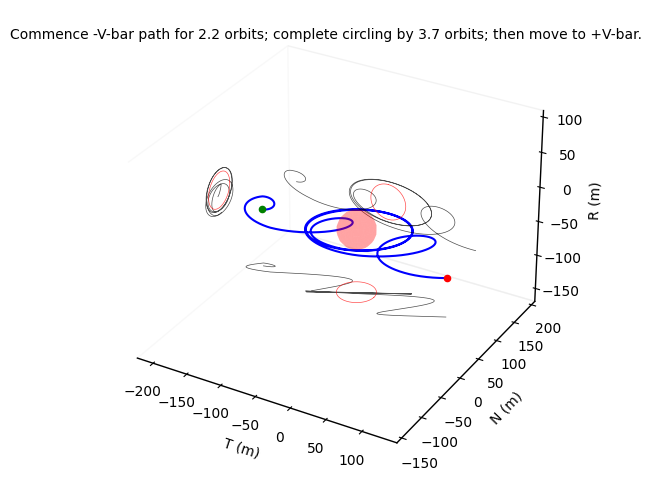

In [9]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')
ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.line.set_color('black')
    axis.line.set_linewidth(1)  # increase thickness

# ax.plot(rtn_DT[1,:], rtn_DT[2,:], rtn_DT[0, :], label='DT Inference', color='blue')
ax.plot(rtn_DT_ct[:, 1], rtn_DT_ct[:, 2], rtn_DT_ct[:, 0], label='DT Inference with CT', color='blue')
ax.scatter(rtn_0[1], rtn_0[2], rtn_0[0], color='green', s=20, label='Start')
ax.scatter(rtn_DT_ct[-1, 1], rtn_DT_ct[-1, 2], rtn_DT_ct[-1, 0], color='red', s=20, label='Goal')
plot_ellipse(ax, radius=param.dim_koz[0], pos=[0,0,0], Ndisc=10, zorder=0)
    
# minimal "projection shadows" onto planes
x_art, y_art, z_art = rtn_DT_ct[:, 0], rtn_DT_ct[:, 1], rtn_DT_ct[:, 2]
x_proj = -90; y_proj = -200; z_proj = 80
alpha = 0.7
ax.plot(y_art, z_art, np.full_like(x_art, x_proj), 'k-', alpha=alpha, linewidth=0.5)  # xy plane (RT)
ax.plot(y_art, np.full_like(z_art, z_proj), x_art, 'k-', alpha=alpha, linewidth=0.5)  # xz plane (RN)
ax.plot(np.full_like(y_art, y_proj), z_art, x_art, 'k-', alpha=alpha, linewidth=0.5)  # yz plane (TN)

# circle (kOZ) projection
phi = np.linspace(0, 2*np.pi, 50)  # tune this to get a better resolution
x_circ = param.dim_koz[0,1]*np.sin(phi); y_circ = param.dim_koz[0,2]*np.cos(phi)
ax.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
ax.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
ax.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)

fig.suptitle(f"{text_command}", fontsize=10, y=0.85)

ax.set_xlabel('T (m)'); ax.set_ylabel('N (m)'); ax.set_zlabel('R (m)')
ax.axis("equal")

### evaluate the trajectory property corresponding to the text 

In [10]:

out_dict = eval_semantics_traj(
    behavior_id = behavior_i,
    cmd_text = text_command,
    template = template_i,
    traj = traj_DT,
    verbose = False,
)
print("errors: ", out_dict)

errors:  {'behavior': 4, 'is_correct': [True, True, True], 'is_correct_with_terminal': [True, True, True], 'd_roef': array([ 0.09074497, -1.20489502, -0.82745814, -0.57423401,  0.14683171,
        0.40997314]), 'd_T_appr_idx': array([ 0.46092364,  3.87978315, -0.35965294, -0.87445831,  0.13605854,
        1.00947571]), 'd_T_circ_idx': array([ 0.05320701,  2.93702602,  0.06898707, -0.68320274,  0.0159038 ,
       -0.66800499])}


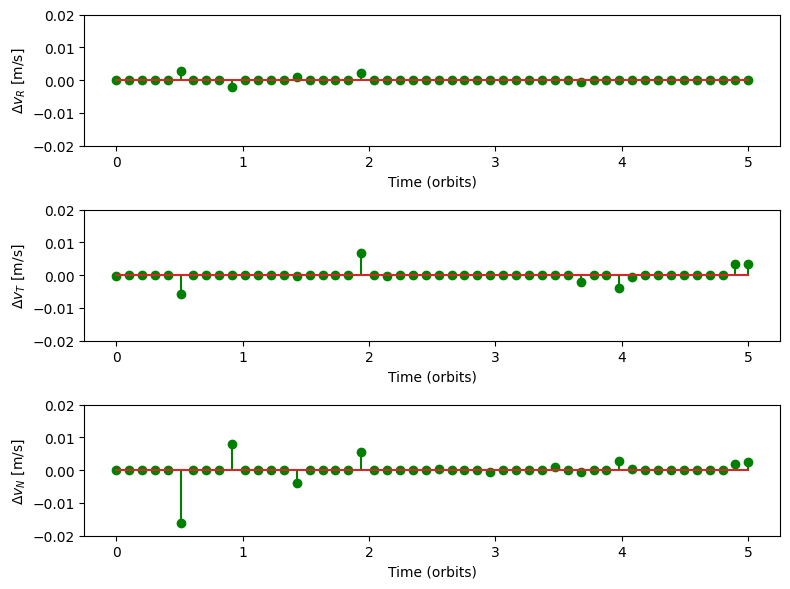

In [11]:
fig = plt.figure(figsize=(8,6))
ax7 = fig.add_subplot(311)
ax7.stem(param.tvec_sec/param.period, traj_DT['dv'][:,0], 'g')
ax7.set_ylabel('$\Delta v_R$ [m/s]')
ax7.set_xlabel('Time (orbits)')
ax8 = fig.add_subplot(312)
ax8.stem(param.tvec_sec/param.period, traj_DT['dv'][:,1], 'g')
ax8.set_ylabel('$\Delta v_T$ [m/s]')
ax8.set_xlabel('Time (orbits)')
ax9 = fig.add_subplot(313)
ax9.stem(param.tvec_sec/param.period, traj_DT['dv'][:,2], 'g')
ax9.set_ylabel('$\Delta v_N$ [m/s]')
ax9.set_xlabel('Time (orbits)')
ax7.set_ylim([-0.02, 0.02]); ax8.set_ylim([-0.02, 0.02]); ax9.set_ylim([-0.02, 0.02])
fig.tight_layout()

### what if we sweep the numbers in the command? 

In [12]:
# behavior 0 
commands = ["Execute 3.0 orbits of approach, then safely circumnavigate the target, avoiding keep-out zones.",
            "Execute 3.2 orbits of approach, then safely circumnavigate the target, avoiding keep-out zones.",
            "Execute 3.6 orbits of approach, then safely circumnavigate the target, avoiding keep-out zones.",
            "Execute 4.0 orbits of approach, then safely circumnavigate the target, avoiding keep-out zones.",
            "Execute 4.5 orbits of approach, then safely circumnavigate the target, avoiding keep-out zones.",
            ]

# example: behavior 5 
commands = ["Commence your approach via -V-bar for 2.0 orbits, proceeding to circumnavigate the target for 1.0 orbits.",
            "Commence your approach via -V-bar for 2.0 orbits, proceeding to circumnavigate the target for 1.5 orbits.",
            "Commence your approach via -V-bar for 2.0 orbits, proceeding to circumnavigate the target for 2.0 orbits.",]

rtn_DT_ct_list = []
roe_DT_list = []

for (i, cmd) in enumerate(commands):
    out_DT = DT_manager.torch_model_inference_dyn(model, data_stats, text_encoder, prob, text_command=cmd, include_final=True)
    traj_DT, runtime_DT = out_DT["traj"], out_DT["runtime"]
    J_DT = sum(np.linalg.norm(traj_DT['dv'], axis=1))
    roe_DT = traj_DT['roe']
    rtn_DT = roe_to_rtn(traj_DT['roe'][:-1], param.oec)
    a_DT = traj_DT['dv']
    _, _, rtn_DT_ct = propagate_ct(roe_DT, a_DT, param.oec, param.tvec_sec)
    
    roe_DT_list.append(roe_DT)
    rtn_DT_ct_list.append(rtn_DT_ct)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

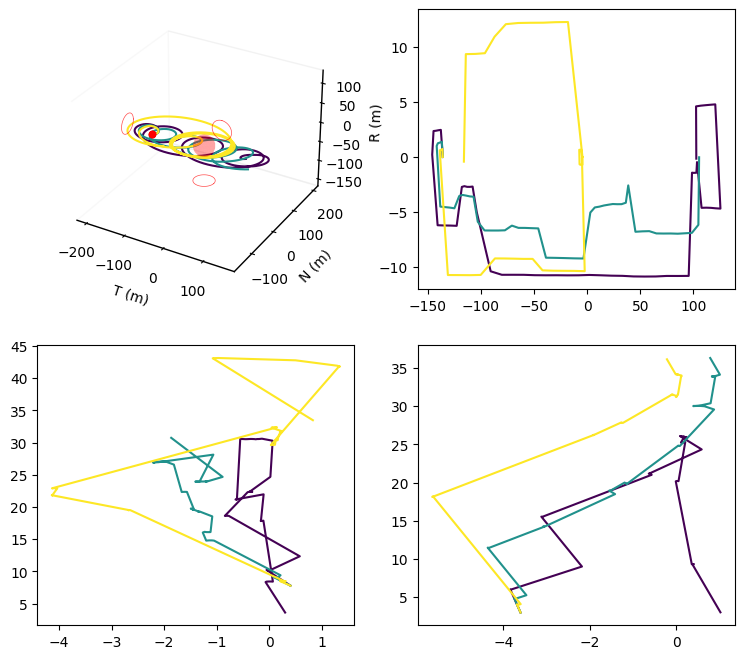

In [13]:

colors = plt.get_cmap('viridis', len(commands))

fig = plt.figure(figsize=(9,8))
ax = fig.add_subplot(221, projection='3d')
ax.set_facecolor('white')
ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.line.set_color('black')
    axis.line.set_linewidth(1)  # increase thickness

for i in range(len(commands)):
    rtn_DT_ct = rtn_DT_ct_list[i]
    ax.plot(rtn_DT_ct[:, 1], rtn_DT_ct[:, 2], rtn_DT_ct[:, 0], color=colors(i))
    ax.scatter(rtn_DT_ct[0, 1], rtn_DT_ct[0, 2], rtn_DT_ct[0,0], color='r', s=20, label='Goal ' + str(i+1))

# circle (kOZ) projection
phi = np.linspace(0, 2*np.pi, 50)  # tune this to get a better resolution
x_circ = param.dim_koz[0,1]*np.sin(phi); y_circ = param.dim_koz[0,2]*np.cos(phi)
ax.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
ax.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
ax.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)
plot_ellipse(ax, radius=param.dim_koz[0], pos=[0,0,0], Ndisc=10, zorder=0)
ax.set_xlabel('T (m)'); ax.set_ylabel('N (m)'); ax.set_zlabel('R (m)')
ax.axis("equal")

# roe plots 
ax2 = fig.add_subplot(222)  
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

for i in range(len(commands)):
    roe_DT = roe_DT_list[i]
    ax2.plot(roe_DT[:, 1], roe_DT[:, 0], color=colors(i))
    ax3.plot(roe_DT[:, 2], roe_DT[:, 3], color=colors(i))
    ax4.plot(roe_DT[:, 4], roe_DT[:, 5], color=colors(i))

ax2.scatter(roe_0[:, 1], roe_0[:,0], color='r', s=20, zorder=5, )
ax3.scatter(roe_0[:, 2], roe_0[:, 3], color='r', s=20, zorder=5)
ax4.scatter(roe_0[:, 4], roe_0[:, 5], color='r', s=20, zorder=5)
ax2.set_xlabel('$a\delta \lambda$ (m)'); ax2.set_ylabel('$a \delta a$ (m)')
ax3.set_xlabel('$a \delta e_x$ (m)'); ax3.set_ylabel('$a \delta e_y$ (m)')
ax4.set_xlabel('$a \delta i_x$ (m)'); ax4.set_ylabel('$a \delta i_y$ (m)')
ax2.axis("equal"); ax3.axis("equal"); ax4.axis("equal")

# colorbar
bounds = np.arange(len(commands) + 1)
norm   = plt.cm.colors.BoundaryNorm(boundaries=bounds, ncolors=len(commands))
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=colors),
    cax=cax,
    orientation='vertical',
)
# optional: ticks at integer "command indices"
cb.set_ticks(np.arange(len(commands)) + 0.5)
cb.set_ticklabels([str(i+1) for i in range(len(commands))])

# ---- build a multiline annotation block ----
text_lines = [f"{i+1}: {cmd}" for i, cmd in enumerate(commands)]
full_text  = "\n".join(text_lines)
fig.text(
    0.02, 0.02,         # x, y position in figure coordinates
    full_text, fontsize=10,
    va='top', ha='left'
)

Text(0.02, 0.02, '1: Commence your approach via -V-bar for 2.0 orbits, proceeding to circumnavigate the target for 1.0 orbits.\n2: Commence your approach via -V-bar for 2.0 orbits, proceeding to circumnavigate the target for 1.5 orbits.\n3: Commence your approach via -V-bar for 2.0 orbits, proceeding to circumnavigate the target for 2.0 orbits.')

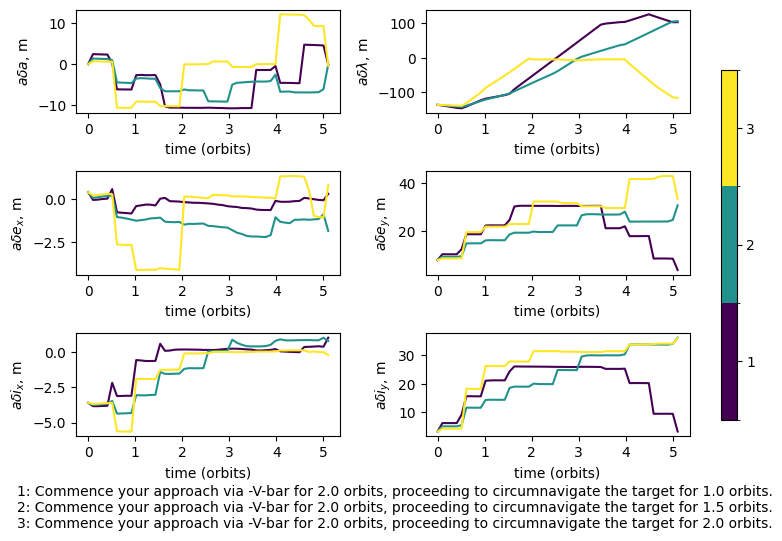

In [14]:
# ROE time history
label = ['$a \delta a$, m', '$a \delta \lambda$, m', '$a \delta e_x$, m', '$a \delta e_y$, m', '$a \delta i_x$, m', '$a \delta i_y$, m']
fig = plt.figure(figsize=(8,5))

t_orbit = np.concatenate([np.arange(param.n_time), [param.n_time]]) * param.dt_sec / param.period

for i in range(6):     
    ax = fig.add_subplot(3,2,i+1)
    for j in range(len(commands)):
        roe_DT = roe_DT_list[j]
        ax.plot(t_orbit, roe_DT[:, i], color=colors(j))
    ax.set_xlabel('time (orbits)')
    ax.set_ylabel(label[i])

fig.tight_layout(rect=[0, 0, 0.88, 1])

# colorbar
bounds = np.arange(len(commands) + 1)
norm   = plt.cm.colors.BoundaryNorm(boundaries=bounds, ncolors=len(commands))
cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
cb = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=colors),
    cax=cax,
    orientation='vertical',
)
# optional: ticks at integer "command indices"
cb.set_ticks(np.arange(len(commands)) + 0.5)
cb.set_ticklabels([str(i+1) for i in range(len(commands))])

# ---- build a multiline annotation block ----
text_lines = [f"{i+1}: {cmd}" for i, cmd in enumerate(commands)]
full_text  = "\n".join(text_lines)
fig.text(
    0.02, 0.02,         # x, y position in figure coordinates
    full_text, fontsize=10,
    va='top', ha='left'
)
